# Building a SimpleRNN Model for Weather Temperature Prediction
## Objective
#### The goal of this assignment is to design, implement, and evaluate a Recurrent Neural Network (RNN) model (using SimpleRNN) to forecast the next day’s temperature based on past weather data.

# Part A: Data Understanding and Preprocessing

## 1. Load the dataset and explore:

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
Data = "weatherHistory.csv"
df = pd.read_csv(Data)
df.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [3]:
df.shape

(96453, 12)

In [4]:
# Check for missing values
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

* Missing value treatment was not performed since only the Precip Type column contained missing values, and it was not used in the analysis.

In [5]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [6]:
# Parsing Dates & Resampling Hourly Data to Daily Data

df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df = df.sort_values("Formatted Date").reset_index(drop=True)

feature_cols = ["Temperature (C)", "Humidity", "Wind Speed (km/h)"]

daily_df = (
    df.set_index("Formatted Date")[feature_cols]
    .resample("D")
    .mean()
    .reset_index()
)

daily_df.head(10)

,Formatted Date,Temperature (C),Humidity,Wind Speed (km/h)
0,2005-12-31 00:00:00+00:00,0.577778,0.890000,17.114300
1,2006-01-01 00:00:00+00:00,4.075000,0.817083,21.229192
2,2006-01-02 00:00:00+00:00,5.263194,0.847083,17.824713
3,2006-01-03 00:00:00+00:00,2.340509,0.897083,7.726658
4,2006-01-04 00:00:00+00:00,2.251852,0.906667,12.152817
5,2006-01-05 00:00:00+00:00,2.703935,0.951250,8.991179
6,2006-01-06 00:00:00+00:00,2.550463,0.945833,5.729588
7,2006-01-07 00:00:00+00:00,0.877083,0.935833,6.589596
8,2006-01-08 00:00:00+00:00,-1.231713,0.868750,5.397525
9,2006-01-09 00:00:00+00:00,-1.693287,0.792500,5.113762


In [7]:
daily_df.shape

(4019, 4)

* Successfully converted 96,453 hourly observations into 4,019 daily records by averaging the readings for each day, resulting in a dataset with one observation per day as required for the analysis.

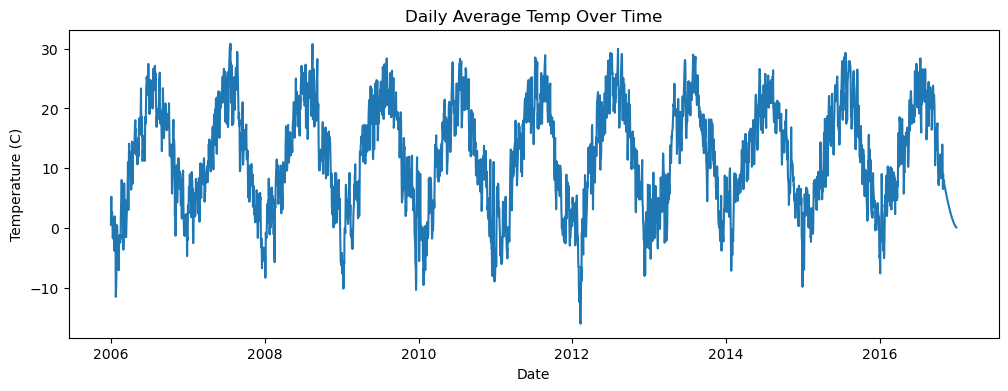

In [8]:
# Plot temperature trends over time
plt.figure(figsize=(12,4))
plt.plot(daily_df['Formatted Date'], daily_df ['Temperature (C)'])
plt.title("Daily Average Temp Over Time")
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.show()

* The temperature plot exhibits a clear annual seasonal pattern, with colder winters (around -10 °C) and warmer summers (around 30 °C) recurring consistently from 2006 to 2016. This indicates strong temporal dependencies and seasonality in the data, making it suitable for RNN-based forecasting

In [9]:
daily_df.isnull().sum()

Formatted Date       0
Temperature (C)      0
Humidity             0
Wind Speed (km/h)    0
dtype: int64

## 2. Preprocess the data:

In [10]:
# Train/ validation/ Test Split (Chronologically)
n = len(daily_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = daily_df.iloc[:train_end]
val_df = daily_df.iloc[train_end:val_end]
test_df = daily_df.iloc[val_end:]

print(len(train_df), len(val_df), len(test_df))

2813 603 603


* The dataset was split chronologically into training (70%), validation (15%), and test (15%) subsets to preserve temporal dependencies and evaluate the model's ability to predict future observations from past weather patterns.

In [11]:
# Normalizing with MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])

train_scaled = scaler.transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

print(train_scaled[:5])

[[0.35354845 0.84946237 0.41866042]
 [0.42831832 0.74492234 0.53358314]
 [0.45372167 0.78793309 0.43850117]
 [0.39123528 0.85961768 0.15647775]
 [0.3893398  0.87335723 0.28009368]]


In [12]:
# Creating Input Sequences
def create_sequence(data, target_col_index, seq_length= 7):
    X,y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i: i+seq_length])
        y.append(data[i+seq_length, target_col_index])
    return np.array(X), np.array(y)
SEQ_LENGTH = 7
TEMP_INDEX = feature_cols.index("Temperature (C)")

X_train, y_train = create_sequence(train_scaled, TEMP_INDEX, SEQ_LENGTH)
X_val, y_val = create_sequence(val_scaled, TEMP_INDEX, SEQ_LENGTH)
X_test, y_test = create_sequence(test_scaled, TEMP_INDEX, SEQ_LENGTH)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(2806, 7, 3) (2806,)
(596, 7, 3) (596,)
(596, 7, 3) (596,)


* The sequence creation produced 2806 training windows, 596 validation and 596 test windows, each containing 7 days of Temperature, Humidity and Wind Speed data. This sliding window format is what allows the RNN to learn from past patterns to predict the next day's temperature.

# Part B: RNN Model Development

## 3. Build a SimpleRNN model using TensorFlow/Keras:

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input

model= Sequential([
    Input(shape=(SEQ_LENGTH, len(feature_cols))),
    SimpleRNN(64, activation="relu"), 
    Dropout(0.2),
    Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile the model:

In [14]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("Model compiled successfully")

Model compiled successfully


## 5. Train the model on training data:

In [15]:
history = model.fit(X_train, y_train,
                   epochs=50,
                   batch_size=32,
                   validation_data=(X_val, y_val),
                   verbose=1
)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0313 - mae: 0.1309 - val_loss: 0.0037 - val_mae: 0.0482
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0132 - mae: 0.0905 - val_loss: 0.0030 - val_mae: 0.0437
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0093 - mae: 0.0767 - val_loss: 0.0027 - val_mae: 0.0413
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0083 - mae: 0.0714 - val_loss: 0.0027 - val_mae: 0.0407
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0073 - mae: 0.0677 - val_loss: 0.0024 - val_mae: 0.0382
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0074 - mae: 0.0675 - val_loss: 0.0022 - val_mae: 0.0364
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0067 - mae: 0.0648 - val_loss: 0.0021 - val_mae: 0.0361
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0063 - mae: 0.0626 - val_loss: 0.0021 - val_mae: 0.0354
Epoch 9/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.006

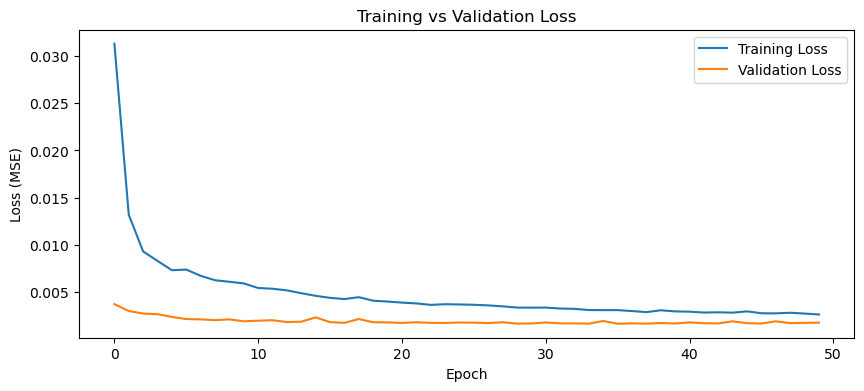

In [16]:
# PLotting Training vs Validation Loss

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

* Training and validation loss decreased consistently and stabilized together, indicating effective learning and good generalization. The slightly lower validation loss is expected due to the use of Dropout during training.

# Part C: Model Evaluation & Forecasting

## 6. Evaluate the model on the test set:

In [17]:
# Get predictions
y_pred_scaled = model.predict(X_test)

# Inverse transform predictions back to Celsius
# Pad to 3 columns because scaler expects 3 features
y_pred_padded = np.zeros((len(y_pred_scaled), len(feature_cols)))
y_pred_padded[:, TEMP_INDEX] = y_pred_scaled.flatten()
y_pred_actual = scaler.inverse_transform(y_pred_padded)[:, TEMP_INDEX]

# Inverse transform actual test values the same way
y_test_padded = np.zeros((len(y_test), len(feature_cols)))
y_test_padded[:, TEMP_INDEX] = y_test
y_test_actual = scaler.inverse_transform(y_test_padded)[:, TEMP_INDEX]

print("First 5 predicted temperatures:", y_pred_actual[:5].round(2))
print("First 5 actual temperatures:", y_test_actual[:5].round(2))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
First 5 predicted temperatures: [13.71 15.53 16.96 19.06 21.21]
First 5 actual temperatures: [15.04 17.53 18.04 22.16 22.45]


* The predicted temperatures closely follow the actual values and correctly capture the increasing trend, suggesting that the model has learned the overall temperature pattern well.

In [18]:
# Calculating RMSE, MAE and R2 Score

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test_actual, y_pred_actual)

print(f"MAE  : {mae:.4f} °C")
print(f"RMSE : {rmse:.4f} °C")
print(f"R²   : {r2:.4f}")

MAE  : 1.5101 °C
RMSE : 1.9723 °C
R²   : 0.9461


* The RNN model achieved an MAE of 1.51 °C, an RMSE of 1.97 °C, and an R² score of 0.9461. These results indicate that the model predicts temperatures with high accuracy, with an average error of approximately 1–2 °C and explaining about 94.6% of the variability in the data.

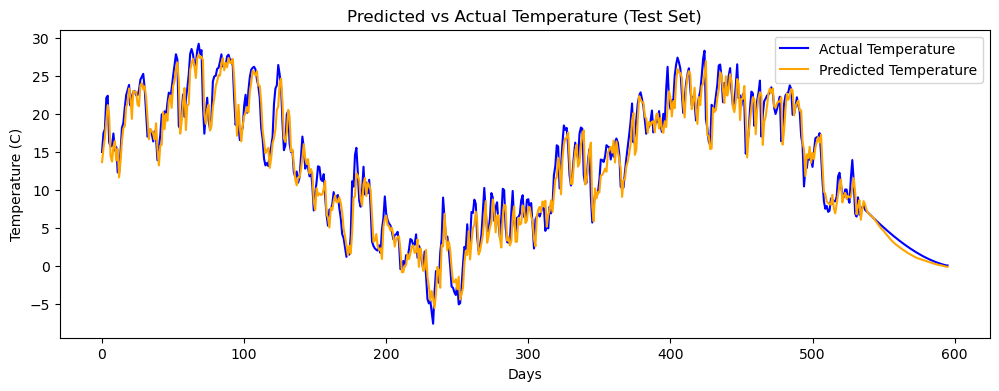

In [20]:
# Plotting Predicted vs Actual Temperatures
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual, label='Actual Temperature', color='blue')
plt.plot(y_pred_actual, label='Predicted Temperature', color='orange')
plt.title('Predicted vs Actual Temperature (Test Set)')
plt.xlabel('Days')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

* The predicted temperatures closely match the actual values throughout the test period, accurately capturing seasonal variations and long-term trends. Small discrepancies occur during abrupt temperature changes, but the overall fit is excellent, supporting the high R² score of 0.9461

## 7. 7-Day Future Temperature Forecast:

In [21]:
# Take the last 7 days from test_scaled as the starting seed
last_sequence = test_scaled[-SEQ_LENGTH:].copy() 

future_predictions = []

for _ in range(7):
    input_seq = last_sequence.reshape(1, SEQ_LENGTH, len(feature_cols))
    next_temp_scaled = model.predict(input_seq, verbose=0)[0, 0]
    next_row = last_sequence[-1].copy()
    next_row[TEMP_INDEX] = next_temp_scaled
    future_predictions.append(next_temp_scaled)
    last_sequence = np.vstack([last_sequence[1:], next_row])

future_padded = np.zeros((7, len(feature_cols)))
future_padded[:, TEMP_INDEX] = future_predictions
future_celsius = scaler.inverse_transform(future_padded)[:, TEMP_INDEX]

print("7-Day Future Temperature Forecast (°C):")
for i, temp in enumerate(future_celsius, 1):
    print(f"Day {i}: {temp:.2f} °C")

7-Day Future Temperature Forecast (°C):
Day 1: -0.04 °C
Day 2: -0.18 °C
Day 3: -0.31 °C
Day 4: -0.39 °C
Day 5: -0.44 °C
Day 6: -0.47 °C
Day 7: -0.49 °C


* The model forecasts temperatures just below 0°C for the next 7 days, gradually decreasing from -0.04°C on Day 1 to -0.49°C on Day 7. This gradual cooling trend is consistent with the winter season visible at the end of the dataset, confirming the model has correctly learned the seasonal pattern.

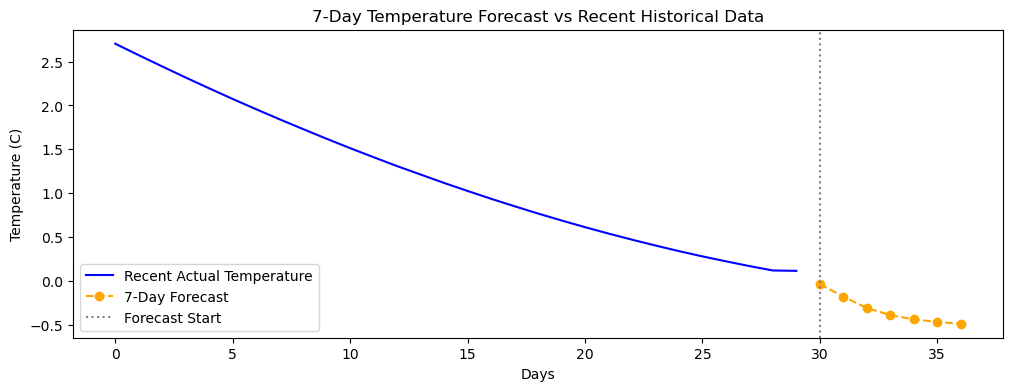

In [22]:
# Visualizing 7-Day Forecast vs Recent Historical Data
recent_actual = y_test_actual[-30:]

plt.figure(figsize=(12, 4))

plt.plot(range(30), recent_actual, label='Recent Actual Temperature', color='blue')

plt.plot(range(30, 37), future_celsius, label='7-Day Forecast', 
         color='orange', linestyle='--', marker='o')

plt.axvline(x=30, color='gray', linestyle=':', label='Forecast Start')
plt.title('7-Day Temperature Forecast vs Recent Historical Data')
plt.xlabel('Days')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

* The plot shows that the observed temperatures over the previous 30 days exhibit a gradual declining trend, indicative of a winter cooling period. The 7-day forecast extends this trend smoothly, predicting temperatures slightly below 0 °C over the forecast horizon. The continuity between the historical observations and forecasted values suggests that the model has effectively captured the recent temporal pattern and produced consistent short-term predictions without abrupt changes.